## 1. Import Libraries

In [205]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


## 2. Load All CSV Files

In [ ]:
files = glob.glob('posts_*.csv')

print(f"Found {len(files)} CSV files:")
for i, file in enumerate(files, 1):
    print(f"  {i}. {file}")
    
    


Found 28 CSV files:
  1. posts_AskReddit_hot.csv
  2. posts_tifu_hot.csv
  3. posts_worldnews_hot.csv
  4. posts_wallstreetbets_hot.csv
  5. posts_gaming_new.csv
  6. posts_movies_hot.csv
  7. posts_NoStupidQuestions_hot.csv
  8. posts_tifu_new.csv
  9. posts_science_hot.csv
  10. posts_wallstreetbets_new.csv
  11. posts_todayilearned_hot.csv
  12. posts_Music_hot.csv
  13. posts_technology_hot.csv
  14. posts_AskReddit_new.csv
  15. posts_technology_new.csv
  16. posts_worldnews_new.csv
  17. posts_movies_new.csv
  18. posts_gaming_hot.csv
  19. posts_pics_hot.csv
  20. posts_AmItheAsshole_new.csv
  21. posts_funny_new.csv
  22. posts_science_new.csv
  23. posts_todayilearned_new.csv
  24. posts_AmItheAsshole_hot.csv
  25. posts_funny_hot.csv
  26. posts_pics_new.csv
  27. posts_wholesomememes_hot.csv
  28. posts_NoStupidQuestions_new.csv


In [ ]:
df_list = []
for file in files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

combined_df = pd.concat(df_list, ignore_index=True)

combined_df.to_csv('combined_posts.csv', index=False)

print(f"\nCombined {len(files)} files into 'combined_posts.csv'")
print(f"Total records: {len(combined_df)}")
print(f"\nDataset shape: {combined_df.shape}")




Combined 28 files into 'combined_posts.csv'
Total records: 29319

Dataset shape: (29319, 9)


## 3. Initial Data Exploration

In [208]:
display(combined_df)

,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit
...,...,...,...,...,...,...,...,...,...
29314,1pi57ma,NoStupidQuestions,How do you think genetic editing will change t...,2,12,1.765280e+09,0.67,True,self.NoStupidQuestions
29315,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1.765280e+09,1.00,True,self.NoStupidQuestions
29316,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1.765280e+09,0.40,True,self.NoStupidQuestions
29317,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1.765280e+09,0.33,True,self.NoStupidQuestions


In [209]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29319 entries, 0 to 29318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            29319 non-null  object 
 1   subreddit     29319 non-null  object 
 2   title         29319 non-null  object 
 3   score         29319 non-null  int64  
 4   num_comments  29319 non-null  int64  
 5   created_utc   29319 non-null  float64
 6   upvote_ratio  29319 non-null  float64
 7   is_self       29319 non-null  bool   
 8   domain        29092 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 1.8+ MB


In [210]:
print("Missing values:")
print(combined_df.isnull().sum())
print(f"\nTotal missing: {combined_df.isnull().sum().sum()}")

Missing values:
id                0
subreddit         0
title             0
score             0
num_comments      0
created_utc       0
upvote_ratio      0
is_self           0
domain          227
dtype: int64

Total missing: 227


In [211]:
print(f"Duplicate posts (by ID): {combined_df['id'].duplicated().sum()}")
print(f"Total unique posts: {combined_df['id'].nunique()}")

Duplicate posts (by ID): 13972
Total unique posts: 15347


## 4. Data Cleaning

In [212]:
original_count = len(combined_df)
combined_df.drop_duplicates(subset='id', inplace=True)
print(f"Removed {original_count - len(combined_df)} duplicate posts")

original_count = len(combined_df)
combined_df.dropna(inplace=True)
print(f"Removed {original_count - len(combined_df)} rows with missing values")

print(f"\nRemaining records: {len(combined_df)}")

display(combined_df)

Removed 13972 duplicate posts
Removed 114 rows with missing values

Remaining records: 15233


,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit
...,...,...,...,...,...,...,...,...,...
29312,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,1.765281e+09,0.50,True,self.NoStupidQuestions
29315,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1.765280e+09,1.00,True,self.NoStupidQuestions
29316,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1.765280e+09,0.40,True,self.NoStupidQuestions
29317,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1.765280e+09,0.33,True,self.NoStupidQuestions


## 5. Features


In [214]:
combined_df['created_utc'] = pd.to_datetime(combined_df['created_utc'], unit='s')

now = pd.Timestamp.now(tz='UTC')

if combined_df['created_utc'].dt.tz is None:
  combined_df['created_utc'] = combined_df['created_utc'].dt.tz_localize('UTC')

combined_df['age_hours'] = (now - combined_df['created_utc']).dt.total_seconds() / 3600.0
original_count = len(combined_df)
combined_df = combined_df[combined_df['age_hours'] > 6]

combined_df['hour-of-day'] = combined_df['created_utc'].dt.hour
combined_df['day-of-week'] = combined_df['created_utc'].dt.day_name()

In [ ]:
combined_df['title_length'] = combined_df['title'].astype(str).apply(len)

plt.figure(figsize=(12, 6))
combined_df.groupby('subreddit')['title_length'].mean().sort_values(ascending=False).plot(kind='bar', color='#2ecc71')
plt.title('Average Title Length by Subreddit', fontsize=14, fontweight='bold')
plt.xlabel('Subreddit')
plt.ylabel('Average Title Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Define Virality Target

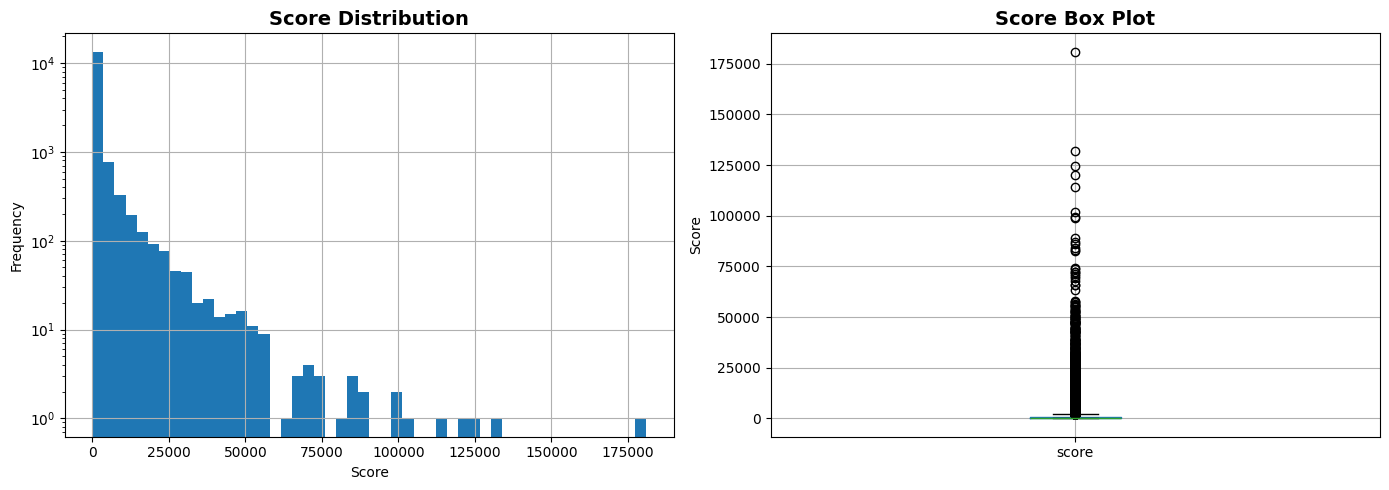

Score statistics:
count     15233.000000
mean       1921.854658
std        6502.180880
min           0.000000
25%           2.000000
50%          63.000000
75%         803.000000
max      180966.000000
Name: score, dtype: float64


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
combined_df['score'].hist(bins=50)
plt.title('Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.yscale('log')

plt.subplot(1, 2, 2)
combined_df.boxplot(column='score')
plt.title('Score Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

print("Score statistics:")
print(combined_df['score'].describe())

In [218]:
viral_threshold = combined_df['score'].quantile(0.75)
combined_df['is_viral'] = combined_df['score'].apply(
    lambda x: 1 if x >= viral_threshold else 0
)

print(f"Viral threshold (75th percentile): {viral_threshold:.0f}")
print(f"\nViral posts: {combined_df['is_viral'].sum()} ({combined_df['is_viral'].mean()*100:.1f}%)")
print(f"Non-viral posts: {(combined_df['is_viral'] == 0).sum()} ({(1-combined_df['is_viral'].mean())*100:.1f}%)")

display(combined_df)

Viral threshold (75th percentile): 803

Viral posts: 3809 (25.0%)
Non-viral posts: 11424 (75.0%)


,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain,age_hours,hour-of-day,day-of-week,title_length,is_viral
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,2025-12-10 16:35:56+00:00,0.83,True,self.AskReddit,26.857165,16,Wednesday,59,0
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,2025-12-10 09:50:06+00:00,0.92,True,self.AskReddit,33.621054,9,Wednesday,73,1
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,2025-12-10 09:07:34+00:00,0.84,True,self.AskReddit,34.329943,9,Wednesday,32,1
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,2025-12-10 15:40:40+00:00,0.93,True,self.AskReddit,27.778276,15,Wednesday,77,0
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,2025-12-10 01:45:37+00:00,0.96,True,self.AskReddit,41.695776,1,Wednesday,69,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29312,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,2025-12-09 11:50:23+00:00,0.50,True,self.NoStupidQuestions,55.616332,11,Tuesday,39,0
29315,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,2025-12-09 11:34:46+00:00,1.00,True,self.NoStupidQuestions,55.876610,11,Tuesday,30,0
29316,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,2025-12-09 11:33:35+00:00,0.40,True,self.NoStupidQuestions,55.896332,11,Tuesday,83,0
29317,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,2025-12-09 11:32:32+00:00,0.33,True,self.NoStupidQuestions,55.913832,11,Tuesday,90,0


## 7. Visualize Processed Data

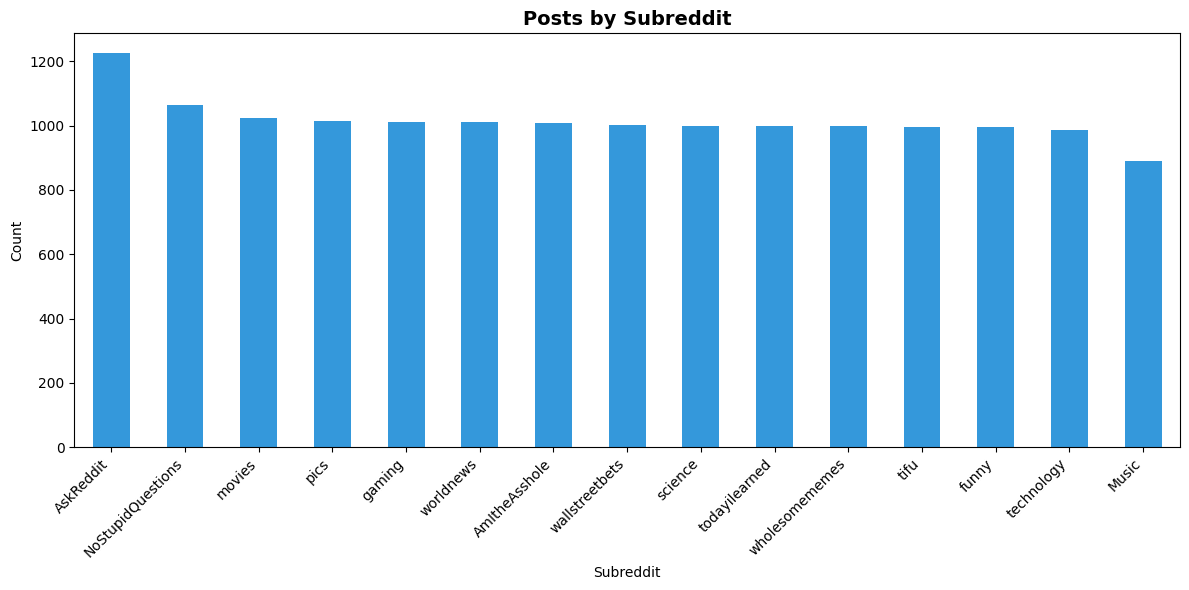

In [219]:
plt.figure(figsize=(12, 6))
combined_df['subreddit'].value_counts().plot(kind='bar', color='#3498db')
plt.title('Posts by Subreddit', fontsize=14, fontweight='bold')
plt.xlabel('Subreddit')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

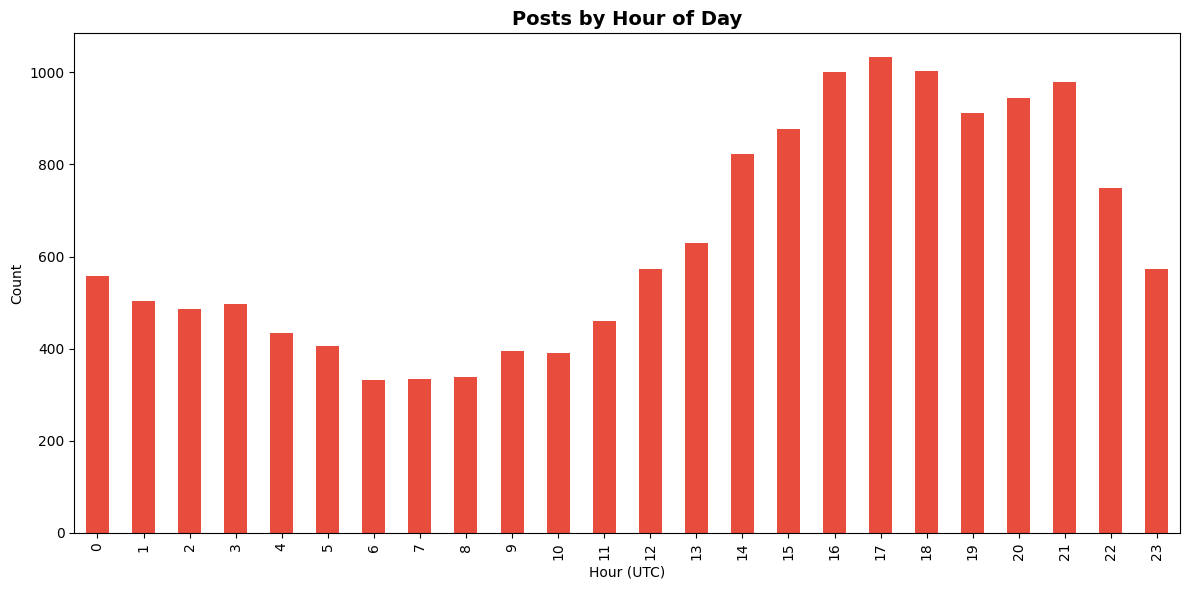

In [220]:
plt.figure(figsize=(12, 6))
combined_df['hour-of-day'].value_counts().sort_index().plot(kind='bar', color='#e74c3c')
plt.title('Posts by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (UTC)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

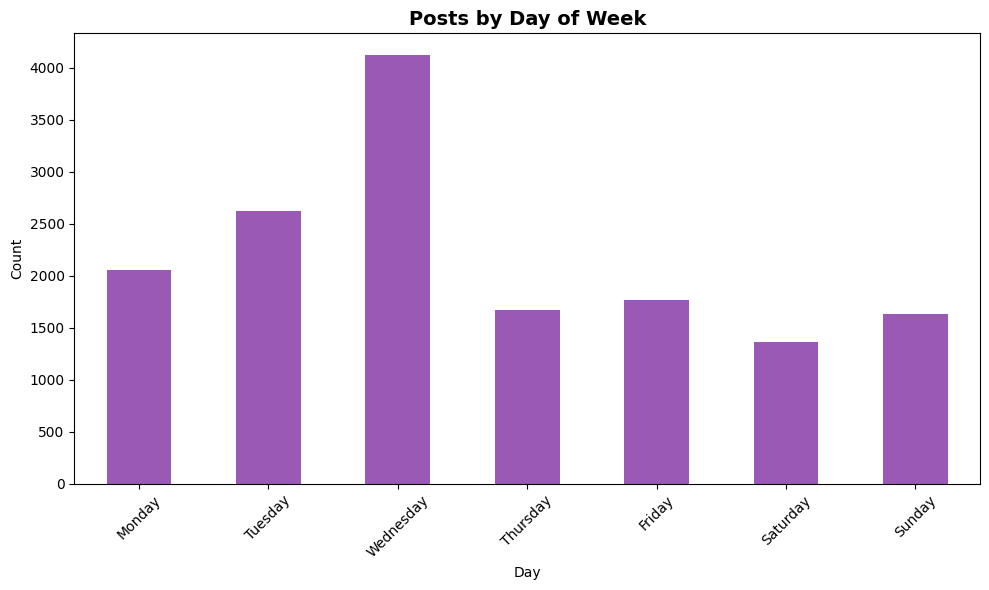

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = combined_df['day-of-week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 6))
day_counts.plot(kind='bar', color='#9b59b6')
plt.title('Posts by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Final Cleanup and Save

In [ ]:
columns_to_drop = ['domain', 'is_self', 'created_utc', 'upvote_ratio', 'num_comments', 'score','id']
existing_columns = [col for col in columns_to_drop if col in combined_df.columns]
combined_df.drop(columns=existing_columns, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"\nRemaining columns: {list(combined_df.columns)}")

Dropped columns: ['domain', 'is_self', 'created_utc', 'upvote_ratio', 'num_comments', 'score', 'id']

Remaining columns: ['subreddit', 'title', 'age_hours', 'hour-of-day', 'day-of-week', 'title_length', 'is_viral']


In [ ]:
combined_df.to_csv('cleaned_combined_posts.csv', index=False)

print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"Cleaned data saved to 'CSV_combined/cleaned_combined_posts.csv'")
print(f"Total records: {len(combined_df)}")
print(f"\nFeatures:")
for col in combined_df.columns:
    print(f"  - {col}")

PREPROCESSING COMPLETE
Cleaned data saved to 'CSV_combined/cleaned_combined_posts.csv'
Total records: 15233

Features:
  - subreddit
  - title
  - age_hours
  - hour-of-day
  - day-of-week
  - title_length
  - is_viral


## 9. Preview Cleaned Data

In [224]:
# Display final cleaned data
print("Final cleaned dataset:")
display(combined_df)

Final cleaned dataset:


,subreddit,title,age_hours,hour-of-day,day-of-week,title_length,is_viral
0,AskReddit,How old were you and how did you find out Sant...,26.857165,16,Wednesday,59,0
1,AskReddit,"In your opinion, what is the best episode of t...",33.621054,9,Wednesday,73,1
2,AskReddit,What do guys “never” tell girls?,34.329943,9,Wednesday,32,1
3,AskReddit,What’s something that instantly gives you “I d...,27.778276,15,Wednesday,77,0
4,AskReddit,What’s the most dangerous thing people do dail...,41.695776,1,Wednesday,69,1
...,...,...,...,...,...,...,...
29312,NoStupidQuestions,My ex stole my cat and got away with it,55.616332,11,Tuesday,39,0
29315,NoStupidQuestions,Least consequential British PM,55.876610,11,Tuesday,30,0
29316,NoStupidQuestions,Anyone else spending more time talking to AI t...,55.896332,11,Tuesday,83,0
29317,NoStupidQuestions,How do people understand that their partner wa...,55.913832,11,Tuesday,90,0


<Axes: >

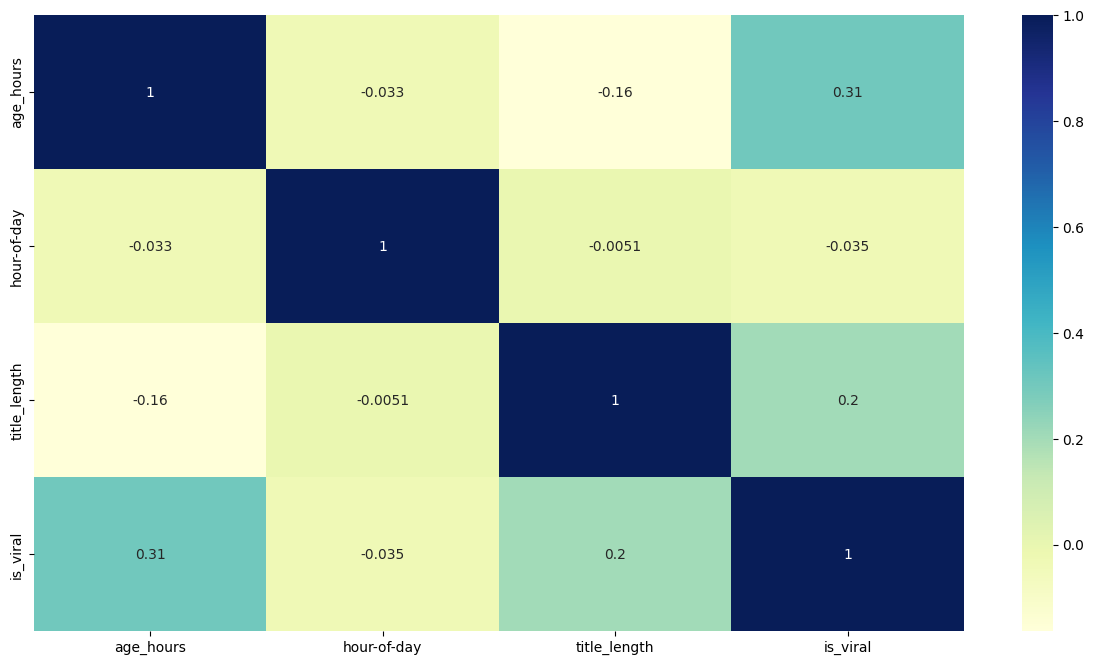

In [225]:
plt.figure(figsize=(15,8))
sns.heatmap(combined_df.select_dtypes(include=np.number).dropna().corr(), cmap="YlGnBu", annot=True)

In [226]:
print("Final dataset info:")
combined_df.info()

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 15233 entries, 0 to 29318
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subreddit     15233 non-null  object 
 1   title         15233 non-null  object 
 2   age_hours     15233 non-null  float64
 3   hour-of-day   15233 non-null  int32  
 4   day-of-week   15233 non-null  object 
 5   title_length  15233 non-null  int64  
 6   is_viral      15233 non-null  int64  
dtypes: float64(1), int32(1), int64(2), object(3)
memory usage: 892.6+ KB
